# COVID 19 Data Analysis Using Python

## Objective

Analyze the global COVID 19 dataset to identify trends, understand the spread of the virus, and generate insights through exploratory data analysis.

## Import Libraries

Import the libraries required for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

## Load the Dataset

Load the COVID 19 dataset into a pandas DataFrame.

In [2]:
df = pd.read_csv("covid_19_clean_complete.csv")

## Dataset Overview

Understand the structure of the dataset by examining its shape, columns, data types, and summary statistics.

In [3]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [4]:
df.tail()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


In [6]:
df.shape

(49068, 10)

In [7]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [9]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [10]:
df.describe(include="object")

,Province/State,Country/Region,Date,WHO Region
count,14664,49068,49068,49068
unique,78,187,188,6
top,Australian Capital Territory,China,2020-01-22,Europe
freq,188,6204,261,15040


In [11]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

Province/State     object
Country/Region     object
Lat               float64
Long              float64
Date               object
Confirmed           int64
Deaths              int64
Recovered           int64
Active              int64
WHO Region         object
dtype: object

## Data Cleaning

Perform data cleaning to improve data quality before analysis.

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df["Date"].dtype

dtype('<M8[ns]')

In [18]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [19]:
df["Country/Region"].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria',
       'Burkina Faso', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Greenland', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon',
       'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala',
       'Guinea', 'Guyana', 'Haiti', 'Holy See', 'Honduras', 'Hungary',
       'Iceland', 'India', 'Ind

In [20]:
df["WHO Region"].unique()

array(['Eastern Mediterranean', 'Europe', 'Africa', 'Americas',
       'Western Pacific', 'South-East Asia'], dtype=object)

In [21]:
df.describe()

,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,2020-04-24 12:00:00,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,2020-04-24 12:00:00,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,2020-06-10 06:00:00,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,2020-07-27 00:00:00,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06
std,24.950320,70.442740,NaN,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04


In [23]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

Province/State    70.114943
Country/Region     0.000000
Lat                0.000000
Long               0.000000
Date               0.000000
Confirmed          0.000000
Deaths             0.000000
Recovered          0.000000
Active             0.000000
WHO Region         0.000000
dtype: float64

In [24]:
df.drop(columns=["Province/State"], inplace=True)

In [25]:
df.columns

Index(['Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

### Data Cleaning

The `Province/State` column contained approximately 70% missing values. Since the objective of this analysis is to study COVID 19 trends at the country level rather than the province level, the column was removed to simplify the dataset.

## Feature Engineering

New features were created from the `Date` column to enable easier time based analysis. These features help identify trends across years, months, days, and weekdays.

In [27]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.day_name()

In [28]:
df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Year,Month,Month_Name,Day,Day_of_Week
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,2020,1,January,22,Wednesday
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,2020,1,January,22,Wednesday
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,2020,1,January,22,Wednesday
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe,2020,1,January,22,Wednesday
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa,2020,1,January,22,Wednesday


## Exploratory Data Analysis

### Question 1: How many countries are represented in the dataset?

This analysis determines the number of unique countries included in the COVID 19 dataset.

In [32]:
df["Country/Region"].nunique()

187

### Question 2: What is the date range of the dataset?

Determine the start and end dates to understand the time period covered by the dataset.

In [33]:
print("Start Date:", df["Date"].min())
print("Start Date:", df["Date"].max())

Start Date: 2020-01-22 00:00:00
Start Date: 2020-07-27 00:00:00


### Question 3: Which WHO regions are included?

Identify the WHO regions represented in the dataset.

In [34]:
df["WHO Region"].value_counts()

WHO Region
Europe                   15040
Western Pacific          10340
Africa                    9024
Americas                  8648
Eastern Mediterranean     4136
South-East Asia           1880
Name: count, dtype: int64

### Question 4: Which countries reported the highest number of confirmed COVID 19 cases?

Since the dataset contains cumulative daily records, the latest record for each country is used to compare the total number of confirmed cases.

In [36]:
latest_data = df.sort_values("Date").groupby("Country/Region").last().reset_index()

In [37]:
latest_data.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Year,Month,Month_Name,Day,Day_of_Week
0,Afghanistan,33.93911,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean,2020,7,July,27,Monday
1,Albania,41.15330,20.168300,2020-07-27,4880,144,2745,1991,Europe,2020,7,July,27,Monday
2,Algeria,28.03390,1.659600,2020-07-27,27973,1163,18837,7973,Africa,2020,7,July,27,Monday
3,Andorra,42.50630,1.521800,2020-07-27,907,52,803,52,Europe,2020,7,July,27,Monday
4,Angola,-11.20270,17.873900,2020-07-27,950,41,242,667,Africa,2020,7,July,27,Monday


In [38]:
top10_confirmed = latest_data.nlargest(10, "Confirmed")
top10_confirmed

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Year,Month,Month_Name,Day,Day_of_Week
173,US,40.000000,-100.000000,2020-07-27,4290259,148011,1325804,2816444,Americas,2020,7,July,27,Monday
23,Brazil,-14.235000,-51.925300,2020-07-27,2442375,87618,1846641,508116,Americas,2020,7,July,27,Monday
79,India,20.593684,78.962880,2020-07-27,1480073,33408,951166,495499,South-East Asia,2020,7,July,27,Monday
138,Russia,61.524010,105.318756,2020-07-27,816680,13334,602249,201097,Europe,2020,7,July,27,Monday
154,South Africa,-30.559500,22.937500,2020-07-27,452529,7067,274925,170537,Africa,2020,7,July,27,Monday
111,Mexico,23.634500,-102.552800,2020-07-27,395489,44022,303810,47657,Americas,2020,7,July,27,Monday
132,Peru,-9.190000,-75.015200,2020-07-27,389717,18418,272547,98752,Americas,2020,7,July,27,Monday
35,Chile,-35.675100,-71.543000,2020-07-27,347923,9187,319954,18782,Americas,2020,7,July,27,Monday
177,United Kingdom,55.378100,-3.436000,2020-07-27,300111,45759,0,254352,Europe,2020,7,July,27,Monday
81,Iran,32.427908,53.688046,2020-07-27,293606,15912,255144,22550,Eastern Mediterranean,2020,7,July,27,Monday


### Visualization 1: Top 10 Countries by Confirmed COVID 19 Cases

The following chart shows the ten countries with the highest cumulative number of confirmed COVID 19 cases based on the latest available records.

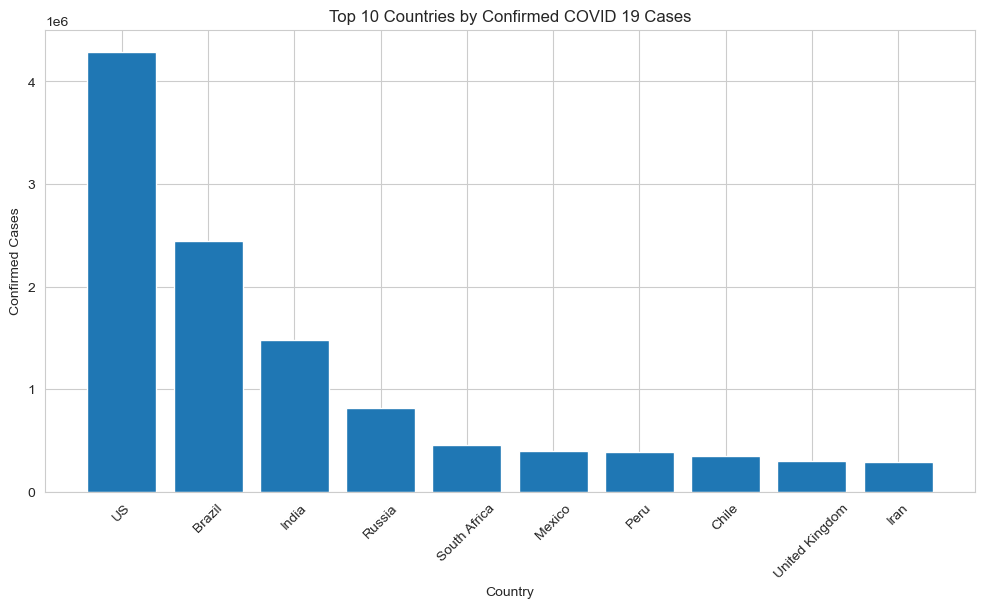

In [39]:
plt.figure(figsize=(12,6))

plt.bar(top10_confirmed["Country/Region"],
        top10_confirmed["Confirmed"])

plt.title("Top 10 Countries by Confirmed COVID 19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=45)

plt.show()

### Insight

The United States reported the highest number of confirmed COVID 19 cases, followed by Brazil and India. The chart highlights that several countries in the Americas were among the most affected during the period covered by the dataset.

### Question 5: Which countries reported the highest number of COVID 19 deaths?

This analysis identifies the ten countries with the highest cumulative number of COVID 19 related deaths based on the latest available records. Understanding the countries with the highest mortality helps assess the global impact of the pandemic.

In [40]:
top10_deaths = latest_data.nlargest(10, "Deaths")

top10_deaths[["Country/Region", "Deaths"]]

,Country/Region,Deaths
173,US,148011
23,Brazil,87618
177,United Kingdom,45759
111,Mexico,44022
85,Italy,35112
79,India,33408
61,France,30096
157,Spain,28432
132,Peru,18418
81,Iran,15912


### Insight

The United States recorded the highest number of deaths, followed by Brazil and the United Kingdom. These countries experienced a significant mortality burden during the period covered by the dataset.

### Visualization 2: Top 10 Countries by COVID 19 Deaths

The following chart displays the ten countries with the highest cumulative number of COVID 19 related deaths based on the latest available records.

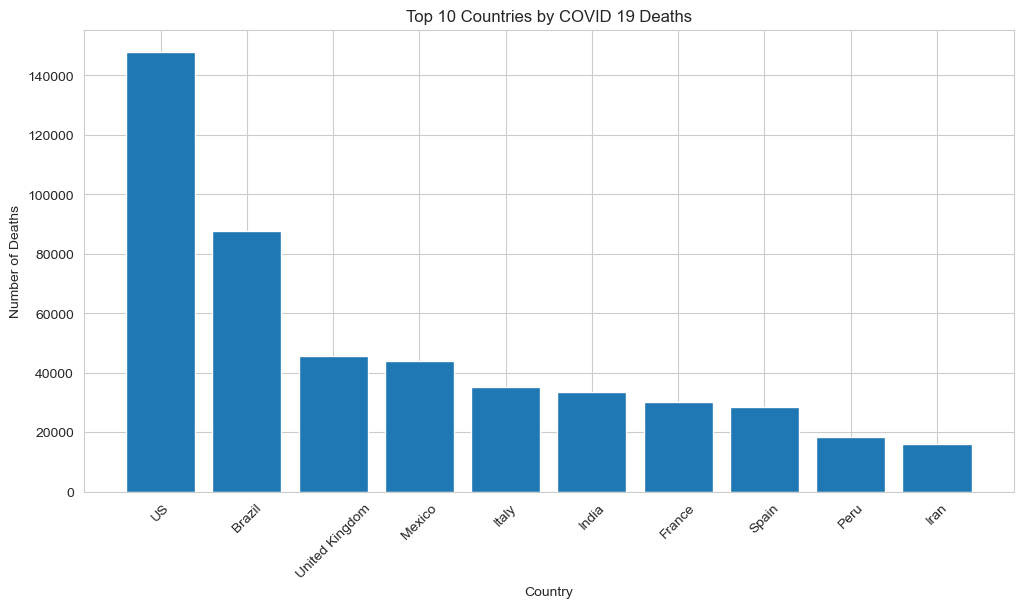

In [67]:
plt.figure(figsize=(12,6))

plt.bar(top10_deaths["Country/Region"],
        top10_deaths["Deaths"])

plt.title("Top 10 Countries by COVID 19 Deaths")
plt.xlabel("Country")
plt.ylabel("Number of Deaths")

plt.xticks(rotation=45)

plt.show()

### Question 6: Which countries had the highest recovery rate?

The recovery rate measures the percentage of confirmed COVID 19 cases that resulted in recovery. This metric helps compare how effectively countries managed patient recoveries, regardless of their total number of confirmed cases.

In [43]:
latest_data["Recovery Rate (%)"] = (
    latest_data["Recovered"] / latest_data["Confirmed"]
) * 100

In [44]:
latest_data["Recovery Rate (%)"] = latest_data["Recovery Rate (%)"].round(2)

In [45]:
top10_recovery = latest_data.nlargest(10, "Recovery Rate (%)")

top10_recovery[["Country/Region", "Recovery Rate (%)"]]

,Country/Region,Recovery Rate (%)
49,Dominica,100.00
69,Grenada,100.00
75,Holy See,100.00
36,China,99.84
48,Djibouti,98.38
78,Iceland,98.33
8,Australia,98.18
24,Brunei,97.87
121,New Zealand,97.24
136,Qatar,97.02


### Data Filtering

Countries with fewer than 10,000 confirmed cases were excluded from the recovery rate analysis. This ensures that the comparison is based on countries with a substantial number of reported cases and avoids misleading percentages from very small datasets.

In [46]:
filtered_data = latest_data[latest_data["Confirmed"] >= 10000]

In [47]:
top10_recovery = filtered_data.nlargest(10, "Recovery Rate (%)")

top10_recovery[["Country/Region", "Confirmed", "Recovery Rate (%)"]]

,Country/Region,Confirmed,Recovery Rate (%)
136,Qatar,109597,97.02
172,Turkey,227019,92.71
35,Chile,347923,91.96
65,Germany,207112,91.89
47,Denmark,13547,91.66
155,South Korea,14203,91.58
12,Bahrain,39482,91.46
83,Ireland,25892,90.24
15,Belarus,67251,89.95
150,Singapore,50838,89.88


### Visualization 3: Top 10 Countries by Recovery Rate

The following chart compares the recovery rates of countries with at least 10,000 confirmed COVID 19 cases.

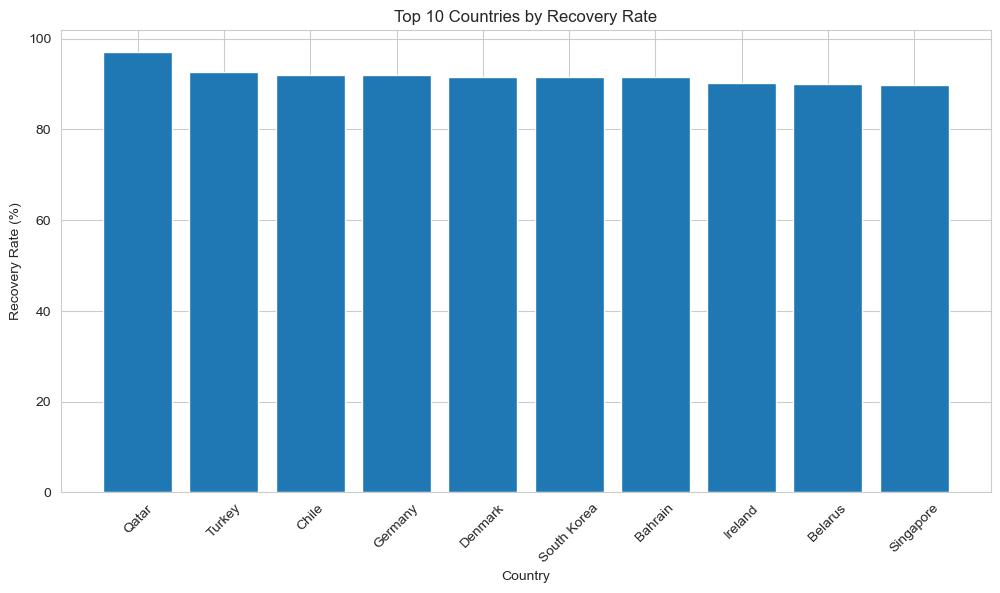

In [68]:
plt.figure(figsize=(12,6))

plt.bar(top10_recovery["Country/Region"],
        top10_recovery["Recovery Rate (%)"])

plt.title("Top 10 Countries by Recovery Rate")
plt.xlabel("Country")
plt.ylabel("Recovery Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Question 7: How did global confirmed COVID 19 cases change over time?

This analysis examines the daily trend of cumulative confirmed COVID 19 cases worldwide to understand how the pandemic evolved over the study period.

In [49]:
daily_cases = df.groupby("Date")["Confirmed"].sum().reset_index()

daily_cases.head()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


### Visualization 4: Global Trend of Confirmed COVID 19 Cases

The following line chart illustrates the growth of cumulative confirmed COVID 19 cases over time.

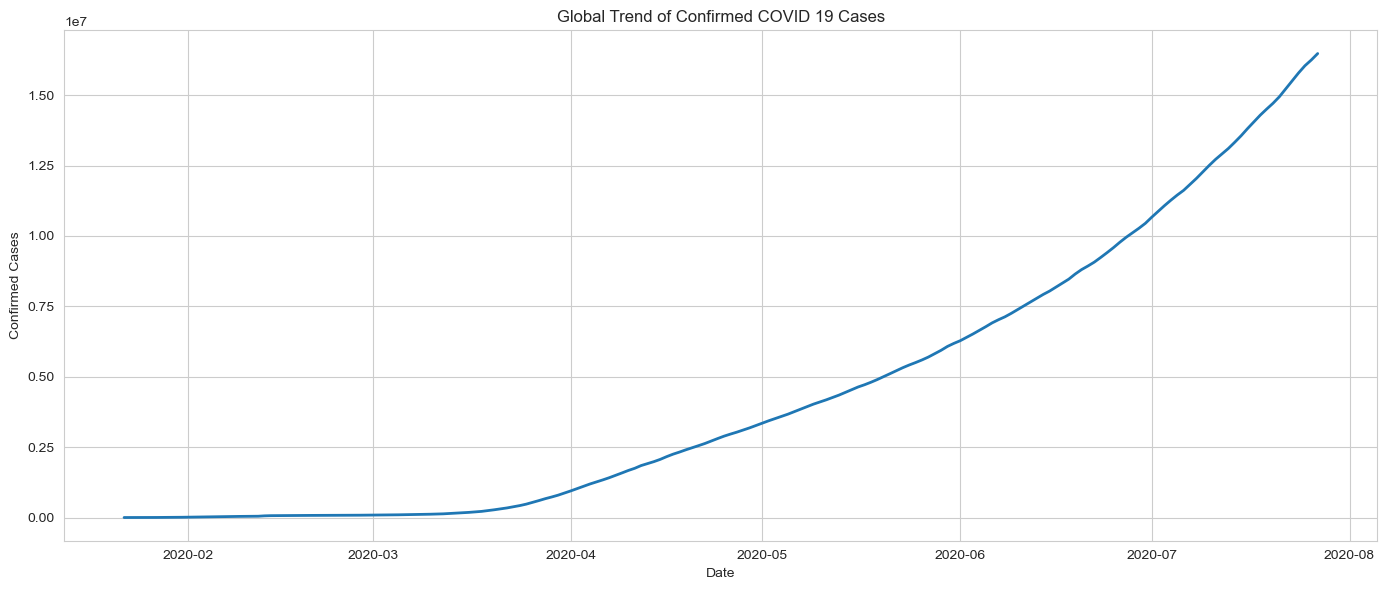

In [69]:
plt.figure(figsize=(14,6))

plt.plot(daily_cases["Date"],
         daily_cases["Confirmed"],
         linewidth=2)

plt.title("Global Trend of Confirmed COVID 19 Cases")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### Insight

The global number of confirmed COVID 19 cases increased steadily throughout the study period, with a sharp rise during the later months. The trend indicates the rapid global spread of the virus over time.

### Question 8: Which WHO Region reported the highest number of confirmed COVID 19 cases?

This analysis compares the cumulative confirmed COVID 19 cases across different WHO regions using the latest available records for each country.

In [55]:
region_cases = latest_data.groupby("WHO Region")["Confirmed"].sum().sort_values(ascending=False)

region_cases

WHO Region
Americas                 8724037
Europe                   3232731
South-East Asia          1835297
Eastern Mediterranean    1490744
Africa                    723207
Western Pacific           192271
Name: Confirmed, dtype: int64

### Visualization 5: Confirmed COVID 19 Cases by WHO Region

The following bar chart compares the total number of confirmed COVID 19 cases across WHO regions.

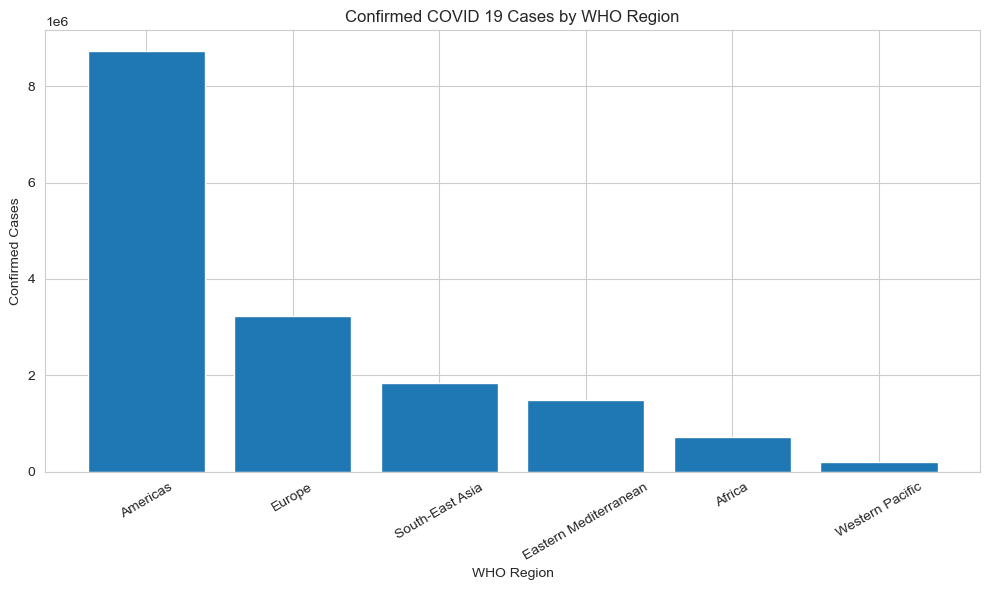

In [70]:
plt.figure(figsize=(10,6))

plt.bar(region_cases.index,
        region_cases.values)

plt.title("Confirmed COVID 19 Cases by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Confirmed Cases")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

### Insight

The chart compares the total confirmed COVID 19 cases across WHO regions. It highlights the regions that experienced the greatest disease burden during the study period and provides a regional perspective on the global pandemic.

### Question 9: Which countries had the highest COVID 19 death rate?

The death rate represents the percentage of confirmed COVID 19 cases that resulted in death. This metric provides a better comparison of disease severity across countries than total deaths alone.

In [57]:
latest_data["Death Rate (%)"] = (
    latest_data["Deaths"] / latest_data["Confirmed"]
) * 100

latest_data["Death Rate (%)"] = latest_data["Death Rate (%)"].round(2)

In [58]:
filtered_data = latest_data[latest_data["Confirmed"] >= 10000]

In [59]:
top10_death_rate = filtered_data.nlargest(10, "Death Rate (%)")

top10_death_rate[["Country/Region", "Confirmed", "Deaths", "Death Rate (%)"]]

,Country/Region,Confirmed,Deaths,Death Rate (%)
177,United Kingdom,300111,45759,15.25
16,Belgium,66428,9822,14.79
61,France,208665,30096,14.42
85,Italy,246286,35112,14.26
111,Mexico,395489,44022,11.13
157,Spain,272421,28432,10.44
161,Sweden,79395,5700,7.18
51,Ecuador,81161,5532,6.82
83,Ireland,25892,1764,6.81
159,Sudan,11424,720,6.30


### Visualization 6: Top 10 Countries by COVID 19 Death Rate

The following chart compares the ten countries with the highest COVID 19 death rates among countries with at least 10,000 confirmed cases.

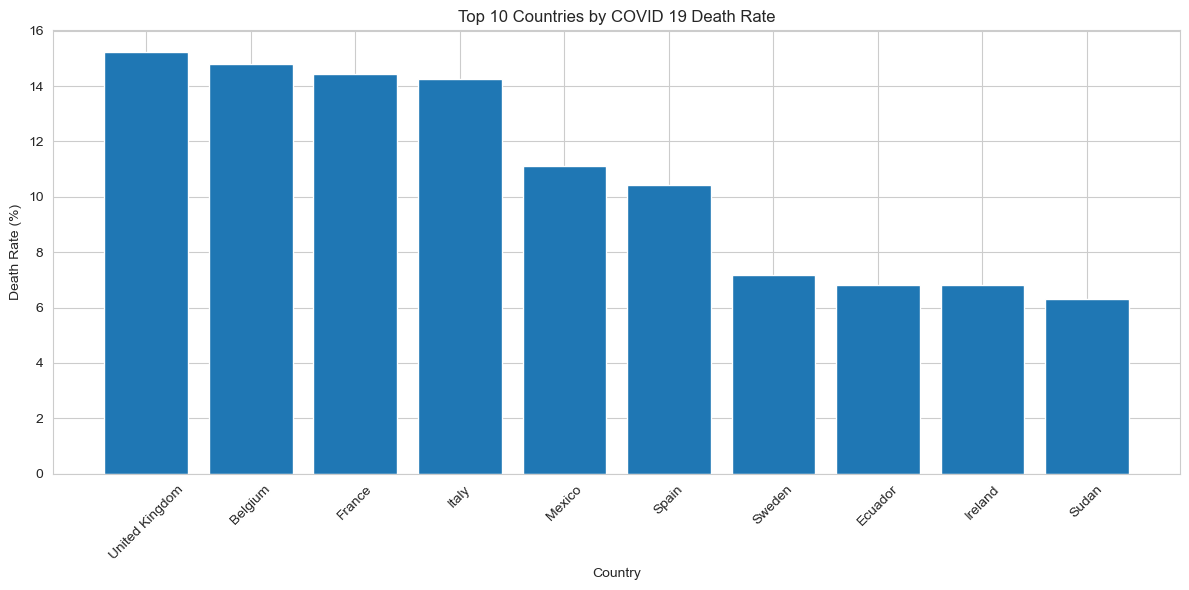

In [60]:
plt.figure(figsize=(12,6))

plt.bar(top10_death_rate["Country/Region"],
        top10_death_rate["Death Rate (%)"])

plt.title("Top 10 Countries by COVID 19 Death Rate")
plt.xlabel("Country")
plt.ylabel("Death Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Insight

The death rate varies considerably across countries, indicating differences in healthcare capacity, testing strategies, demographics, and pandemic response. Comparing death rates provides a more meaningful assessment than comparing total deaths alone.

## Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between numerical variables. A heatmap provides a visual representation of these relationships, making it easier to identify strong positive or negative correlations.

In [61]:
numerical_data = latest_data[
    ["Confirmed", "Deaths", "Recovered", "Active"]
]

In [62]:
correlation_matrix = numerical_data.corr()

correlation_matrix

,Confirmed,Deaths,Recovered,Active
Confirmed,1.000000,0.935045,0.906831,0.927287
Deaths,0.935045,1.000000,0.833377,0.871725
Recovered,0.906831,0.833377,1.000000,0.683412
Active,0.927287,0.871725,0.683412,1.000000


### Visualization 7: Correlation Heatmap

The heatmap illustrates the correlation between key numerical variables in the dataset. Correlation values range from -1 to 1, where values closer to 1 indicate a strong positive relationship.

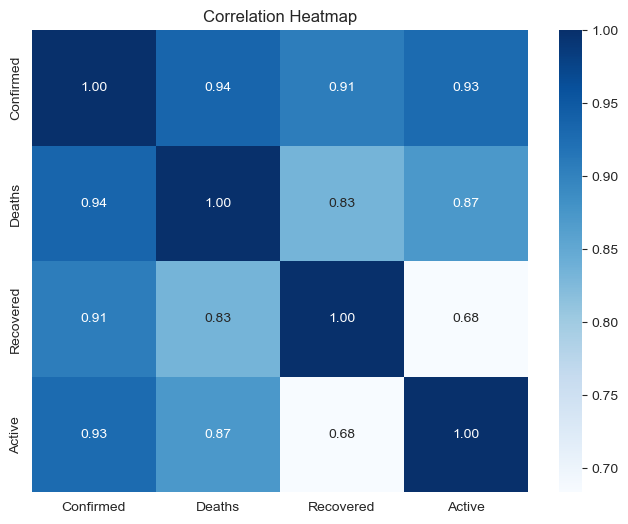

In [71]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight

The heatmap shows strong positive correlations among confirmed, deaths, recovered, and active cases. This indicates that countries with higher confirmed cases generally reported higher numbers of deaths, recoveries, and active cases.

## Distribution of Confirmed Cases

Understanding the distribution of confirmed COVID 19 cases helps identify whether cases are evenly spread across countries or concentrated in a few highly affected countries.

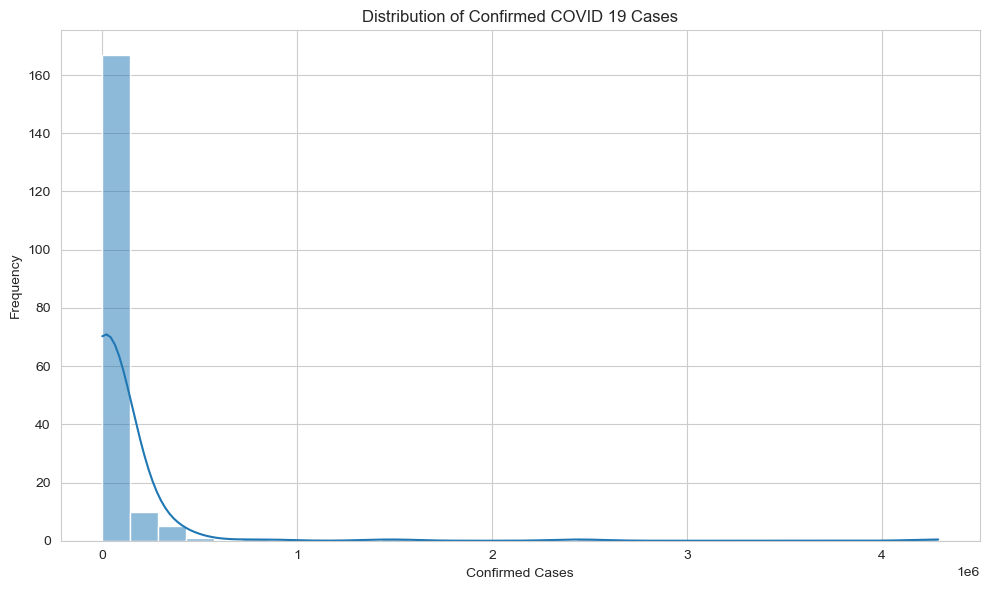

In [72]:
plt.figure(figsize=(10,6))

sns.histplot(
    latest_data["Confirmed"],
    bins=30,
    kde=True
)

plt.title("Distribution of Confirmed COVID 19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Insight

The distribution of confirmed COVID 19 cases is highly right skewed. Most countries reported relatively low numbers of confirmed cases, while a small number of countries accounted for exceptionally high case counts. This indicates that the pandemic's burden was concentrated in a few heavily affected countries.

## Relationship Between Confirmed Cases and Deaths

A scatter plot is used to examine the relationship between confirmed COVID 19 cases and deaths across countries. Each point represents a country.

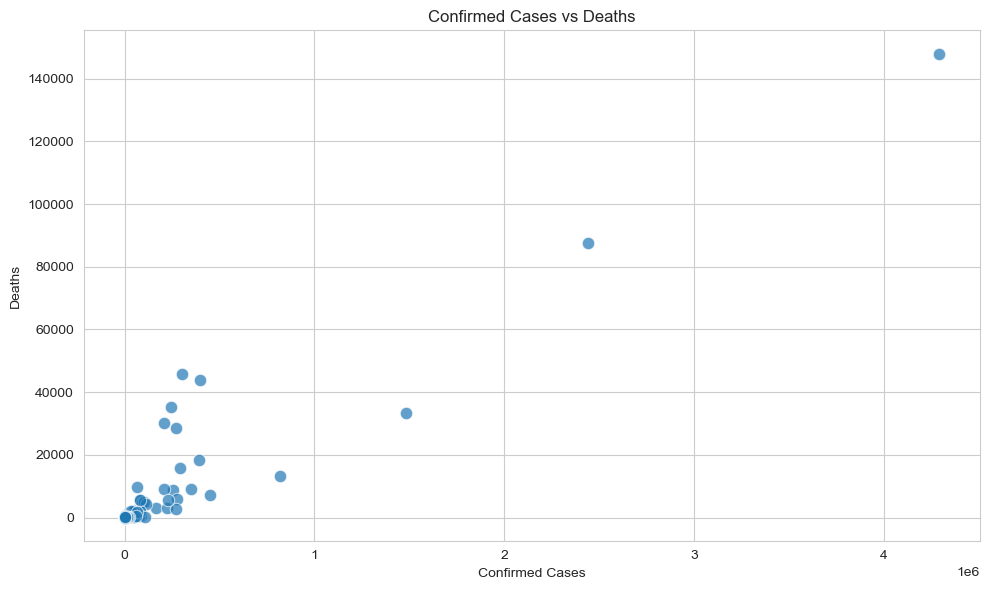

In [73]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=latest_data,
    x="Confirmed",
    y="Deaths",
    s=80,
    alpha=0.7
)

plt.title("Confirmed Cases vs Deaths")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")

plt.tight_layout()

plt.show()

### Insight

The scatter plot reveals a strong positive relationship between confirmed COVID 19 cases and deaths. Most countries reported relatively low case and death counts, while a few countries appeared as outliers with exceptionally high values. These outliers reflect the disproportionate impact of the pandemic on heavily affected countries.

## Key Takeaways

- **Case burden was concentrated, not evenly spread.** A small number of countries (US, India, Brazil) accounted for a disproportionate share of global confirmed cases, while most countries reported comparatively low totals — confirmed by the right-skewed distribution.

- **Raw counts overstate the impact of large countries.** When adjusted for population, the ranking of "most affected" countries changes meaningfully — smaller countries with high cases-per-million show a more concentrated outbreak relative to their size than raw totals suggest. This distinction matters for any resource allocation or policy decision based on this data.

- **Recovery and death rates vary independently of case volume.** Countries with the highest confirmed case counts were not necessarily the ones with the best or worst outcome rates, indicating that factors like healthcare capacity, testing strategy, and response timing mattered more than case volume alone.

- **Confirmed cases, deaths, recovered, and active cases are strongly correlated**, which is expected given they're derived from the same underlying spread — but the *rates* built from them (death rate, recovery rate) tell a more nuanced story than the raw totals do.

- **Regional disparity was significant.** WHO regions differed substantially in total case burden, reflecting differences in population density, response timing, and healthcare infrastructure across regions.

### Limitations
- Death/recovery rates are computed from a single end-of-period snapshot, not adjusted for reporting lag between infection and outcome — so they're a rough proxy for severity, not a precise case-fatality rate.
- Population data was manually mapped for a subset of countries; countries without a population match are excluded from per-capita comparisons.
- Recovered-case reporting was known to be inconsistent across countries in this dataset, so recovery rate comparisons should be treated as directional rather than exact.